Found 46 valid records.
Excluded records: ['102', '104']
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 da

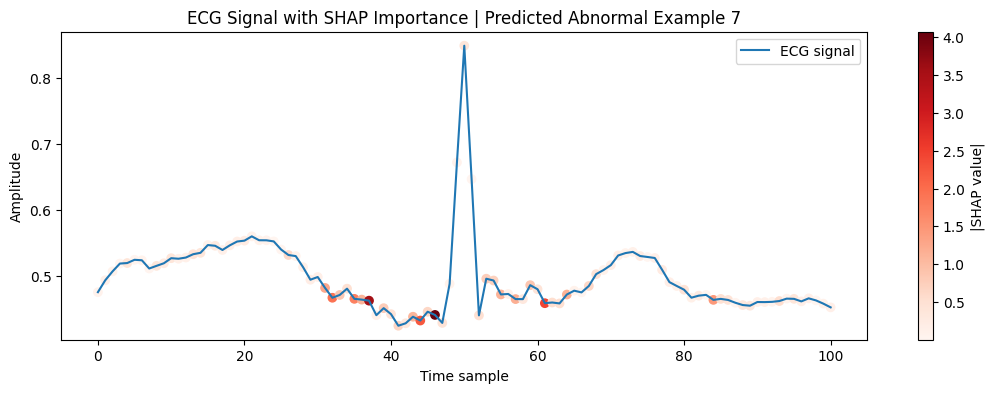

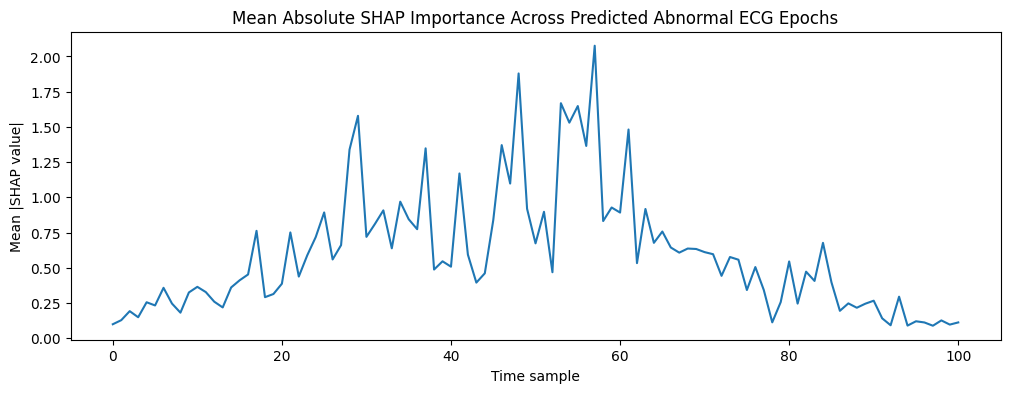

In [16]:
import torch 
import torch.nn as nn
import shap
import numpy as np 
import matplotlib.pyplot as plt

from cnn_model import ECGCNN1D
from file_aggregation import file_aggregation

# Load data
X, y, groups = file_aggregation(
    "/Users/reymendoza/Downloads/mit-bih-arrhythmia-database-1.0.0"
)

X_tensor = torch.tensor(X, dtype=torch.float32)

if X_tensor.ndim == 2:
    X_tensor = X_tensor.unsqueeze(1)

y_tensor = torch.tensor(y)

print("Input shape:", X_tensor.shape)

# Model
model = ECGCNN1D()

checkpoint = torch.load(
    "/Users/reymendoza/Developer/EKG/model/saved_models/ecg_cnn_v1_best_overall.pt",
    map_location="cpu",
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Normal Examples
normal_indices = torch.where(y_tensor == 0)[0]
background = X_tensor[normal_indices[:50]]

print("Background shape:", background.shape)

# Abnormal Examples
X_trunc = X_tensor[:20000]

batch_size = 512
all_probs = []

with torch.no_grad():
    for i in range(0, len(X_trunc), batch_size):
        X_batch = X_trunc[i:i + batch_size]
        logits = model(X_batch)
        probs = torch.sigmoid(logits).squeeze()
        all_probs.append(probs.cpu())

probs = torch.cat(all_probs)

abnormal_indices = torch.where(probs > 0.5)[0]

print("Number of predicted abnormal examples:", len(abnormal_indices))

if len(abnormal_indices) == 0:
    raise ValueError("No predicted abnormal examples found. Try using a lower threshold or true labels.")

test_examples = X_trunc[abnormal_indices[:20]]

print("Test examples shape:", test_examples.shape)

# SHAP
explainer = shap.DeepExplainer(model, background)

shap_values = explainer.shap_values(
    test_examples,
    check_additivity=False
)

if isinstance(shap_values, list):
    shap_array = shap_values[0]
else:
    shap_array = shap_values

shap_array = np.array(shap_array)

print("SHAP shape:", shap_array.shape)

example_idx = 7

ecg_signal = test_examples[example_idx, 0, :].detach().numpy()
ecg_shap = shap_array[example_idx, 0, :]

plt.figure(figsize=(13, 4))
plt.plot(ecg_signal, label="ECG signal")
plt.scatter(
    np.arange(len(ecg_signal)),
    ecg_signal,
    c=np.abs(ecg_shap),
    cmap="Reds"
)
plt.colorbar(label="|SHAP value|")
plt.title(f"ECG Signal with SHAP Importance | Predicted Abnormal Example {example_idx}")
plt.xlabel("Time sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

mean_abs_shap = np.mean(np.abs(shap_array[:, 0, :]), axis=0)

plt.figure(figsize=(12, 4))
plt.plot(mean_abs_shap)
plt.title("Mean Absolute SHAP Importance Across Predicted Abnormal ECG Epochs")
plt.xlabel("Time sample")
plt.ylabel("Mean |SHAP value|")
plt.show()
